<a href="https://colab.research.google.com/github/IT22283344/DL_Assignment/blob/Manuja/VGG16_Garbage_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
cd "/content/drive/MyDrive/Colab Notebooks/DL_Assignment"

/content/drive/MyDrive/Colab Notebooks/DL_Assignment


In [22]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt


In [23]:
# Define paths and parameters
train_dir = '/content/drive/MyDrive/Colab Notebooks/DL_Assignment/DATASET/TRAIN'
test_dir = '/content/drive/MyDrive/Colab Notebooks/DL_Assignment/DATASET/TEST'
img_width, img_height = 224, 224 # VGG16 input size
batch_size = 32

# Data pre processing and augmentation

In [24]:
# Create ImageDataGenerator for training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values
    shear_range=0.2, # Apply shear augmentation
    zoom_range=0.2, # Apply zoom augmentation
    horizontal_flip=True) # Apply horizontal flip augmentation

# Create ImageDataGenerator for testing (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255) # Normalize pixel values

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary') # Use 'binary' for binary classification

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary') # Use 'binary' for binary classification

# Map class indices to labels
class_labels = {0: 'Organic', 1: 'Recycle'}

Found 22592 images belonging to 2 classes.
Found 2514 images belonging to 2 classes.


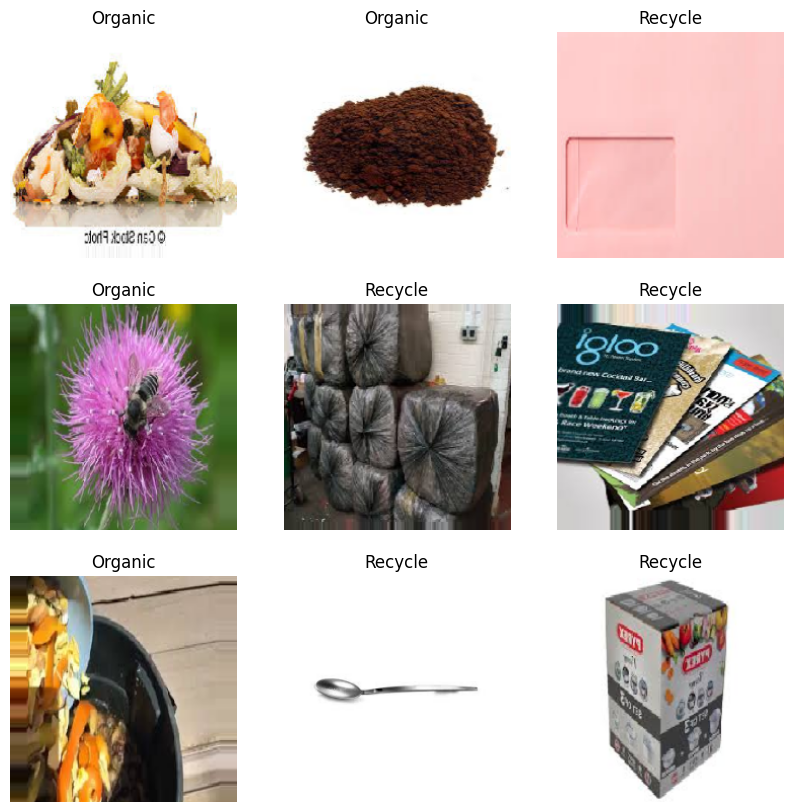

In [25]:
import matplotlib.pyplot as plt

# Get a batch of images and labels from the training generator
images, labels = next(train_generator)

# Get the class names from the generator
class_names = list(train_generator.class_indices.keys())

# Plot the first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_labels[int(labels[i])]) # Use the updated class_labels dictionary
    plt.axis("off")
plt.show()